# Custom Loss CBAM Validation

This notebook mirrors `validation/cbam_nnunet.ipynb` and runs validation visualizations for the custom-loss CBAM checkpoints in `experiments/custom_loss_cbam`.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch

from models.cbam_nnunet import nnUNet3D_CBAM
from utils.unets_helper_functions import show_difference_map, sliding_window_cbam


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# The folder currently contains an extra 05_sc checkpoint, but this list follows the six-model set requested.
MODEL_PATHS = {
    "04_iw": "../experiments/custom_loss_cbam/04_iw_best_combined_model.pth",
    "04_rw": "../experiments/custom_loss_cbam/04_rw_best_combined_model.pth",
    "04_sc": "../experiments/custom_loss_cbam/04_sc_best_combined_model.pth",
    "05_sc": "../experiments/custom_loss_cbam/05_sc_best_combined_model.pth",
    "06_iw": "../experiments/custom_loss_cbam/06_iw_best_combined_model.pth",
    "06_rw": "../experiments/custom_loss_cbam/06_rw_best_combined_model.pth",
    "06_sc": "../experiments/custom_loss_cbam/06_sc_best_combined_model.pth",
}

missing = [name for name, path in MODEL_PATHS.items() if not Path(path).exists()]
if missing:
    raise FileNotFoundError(f"Missing checkpoints: {missing}")

for name, path in MODEL_PATHS.items():
    print(f"{name}: {path}")


Using device: cuda
04_iw: ../experiments/custom_loss_cbam/04_iw_best_combined_model.pth
04_rw: ../experiments/custom_loss_cbam/04_rw_best_combined_model.pth
04_sc: ../experiments/custom_loss_cbam/04_sc_best_combined_model.pth
05_sc: ../experiments/custom_loss_cbam/05_sc_best_combined_model.pth
06_iw: ../experiments/custom_loss_cbam/06_iw_best_combined_model.pth
06_rw: ../experiments/custom_loss_cbam/06_rw_best_combined_model.pth
06_sc: ../experiments/custom_loss_cbam/06_sc_best_combined_model.pth


In [4]:
FOLD = 0
CASE_INDEX = 8
PATCH_SIZE = 96
STRIDE = 48
SLICE_INDEX = None  # Set an integer to override the middle slice.

with open(f"../data/splits/fold_{FOLD}/train.txt") as f:
    train_cases = f.read().splitlines()

with open(f"../data/splits/fold_{FOLD}/val.txt") as f:
    val_cases = f.read().splitlines()

case = val_cases[CASE_INDEX]
print("Testing case:", case)

image = nib.load(f"../data/processed/imagesTr/{case}.nii.gz").get_fdata()
label = nib.load(f"../data/processed/labelsTr/{case}.nii.gz").get_fdata()

z = image.shape[0] // 2 if SLICE_INDEX is None else SLICE_INDEX
ct_slice = image[z]
gt_slice = label[z]

print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Slice index:", z)


Testing case: case_02
Image shape: (272, 466, 466)
Label shape: (272, 466, 466)
Slice index: 136


In [5]:
def load_cbam_model(model_path, device):
    model = nnUNet3D_CBAM(
        in_channels=1,
        out_channels=7,
        base_filters=24
    ).to(device)

    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

results = {}

for model_name, model_path in MODEL_PATHS.items():
    print(f"\nRunning inference for {model_name}...")
    model = load_cbam_model(model_path, device)
    pred = sliding_window_cbam(
        model,
        image,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        device=device
    )
    results[model_name] = {
        "pred": pred,
        "pred_slice": pred[z],
        "unique_labels": np.unique(pred)
    }
    print(f"Prediction shape: {pred.shape}")
    print(f"Unique labels: {results[model_name]['unique_labels']}")
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



Running inference for 04_iw...


C:\Users\dhanu\AppData\Local\Temp\ipykernel_10536\4125277941.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]

Running inference for 04_rw...
Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]

Running inference for 04_sc...
Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]

Running inference for 05_sc...
Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]

Running inference for 06_iw...
Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]

Running inference for 06_rw...
Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]

Running inference for 06_sc...
Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)
Unique labels: [0 1 2 3 4 5 6]


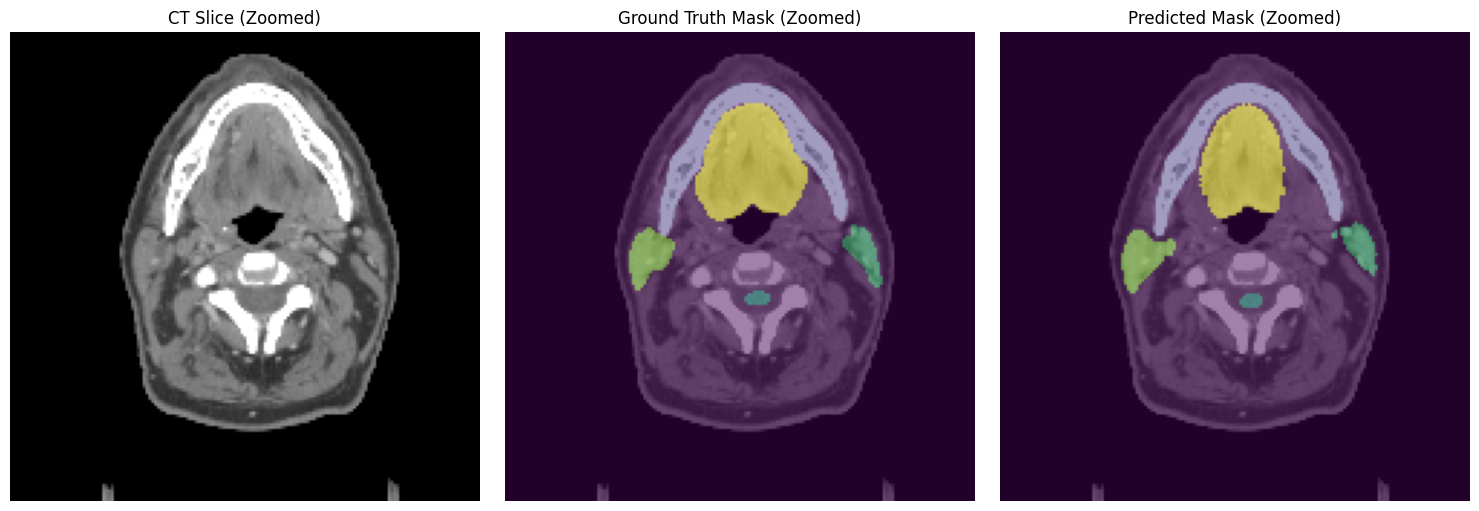

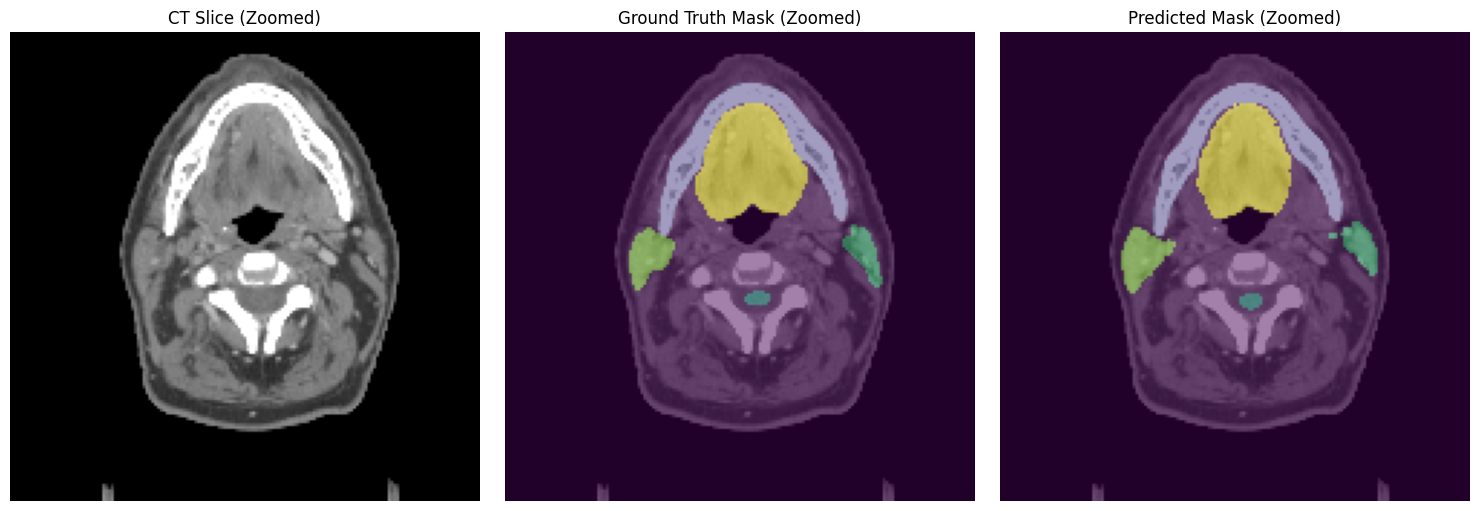

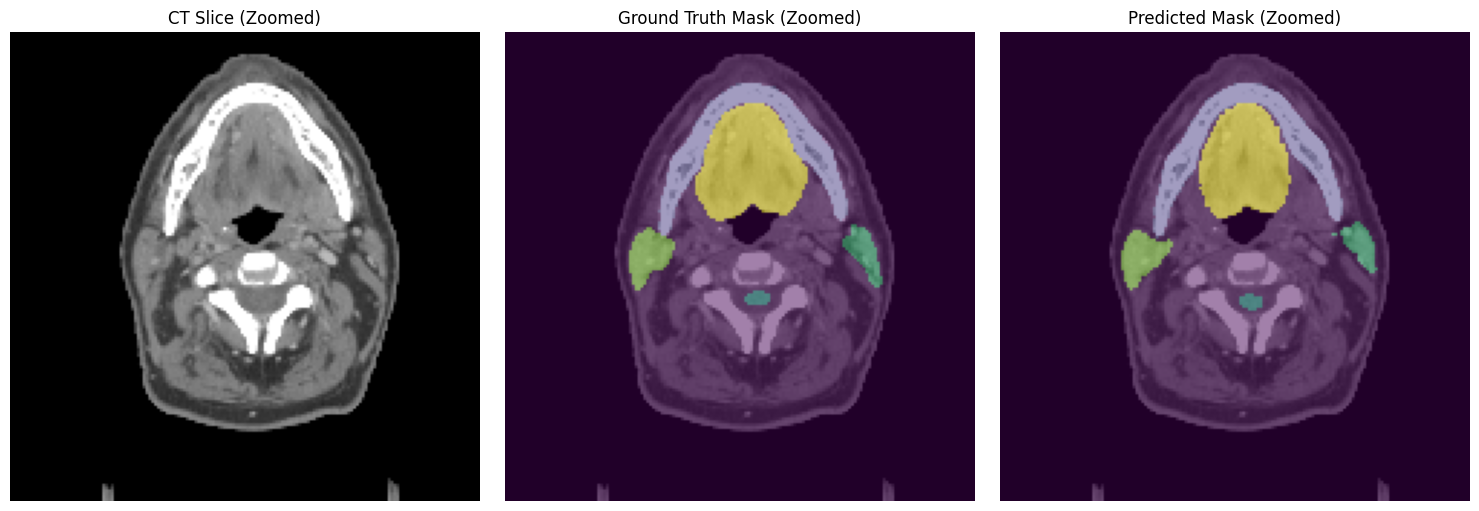

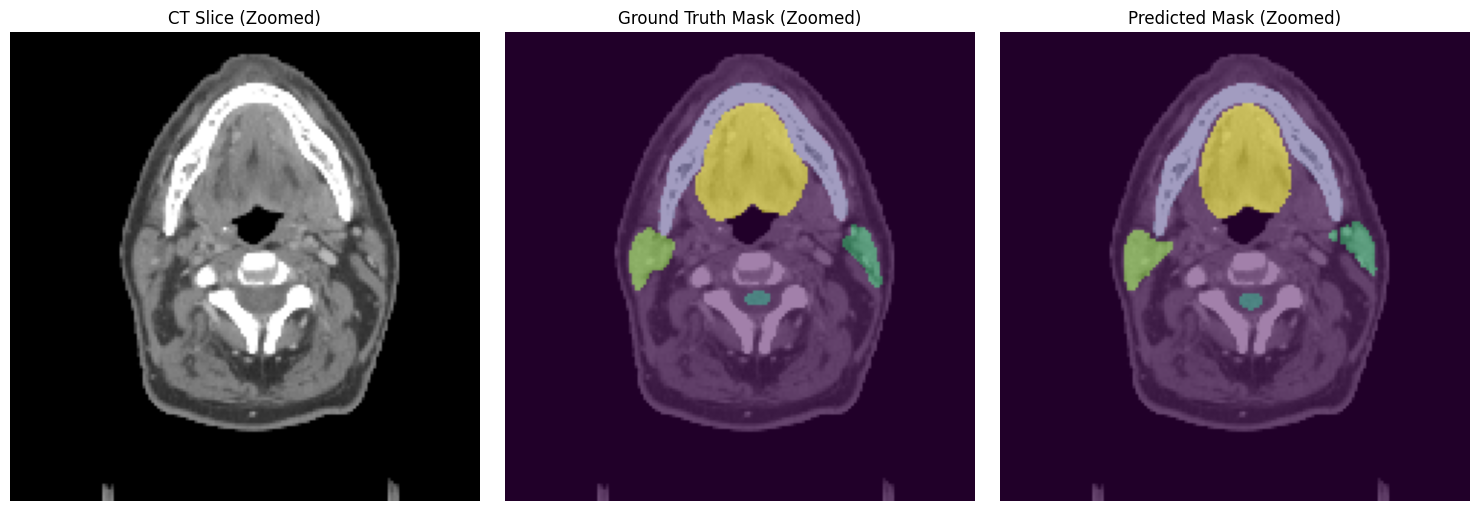

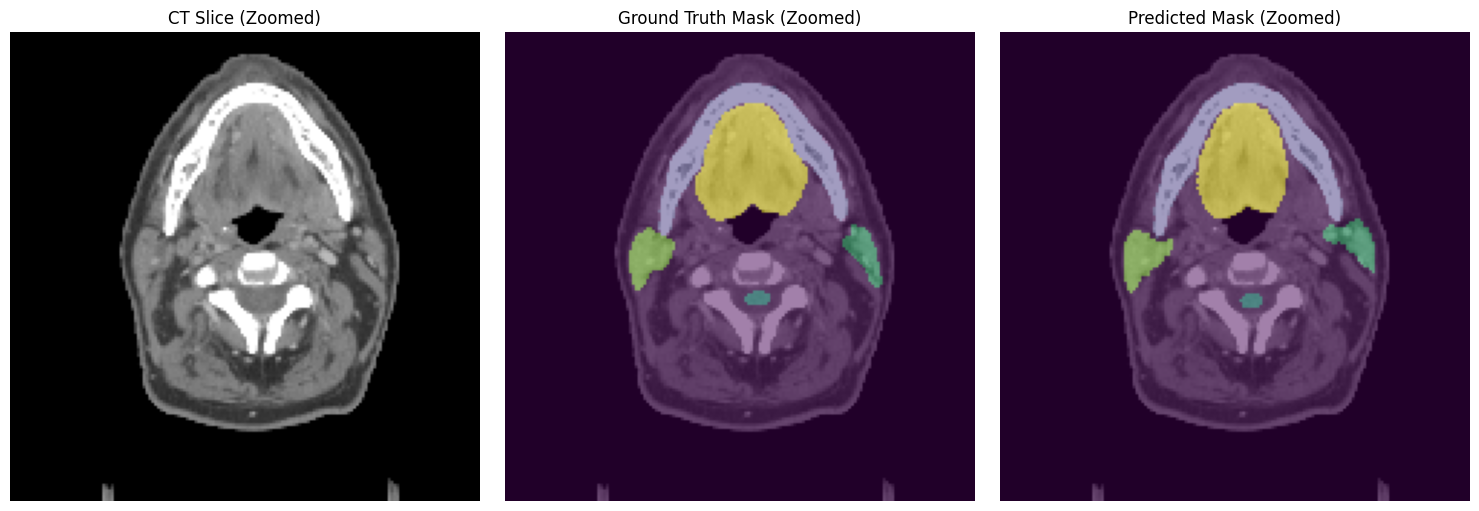

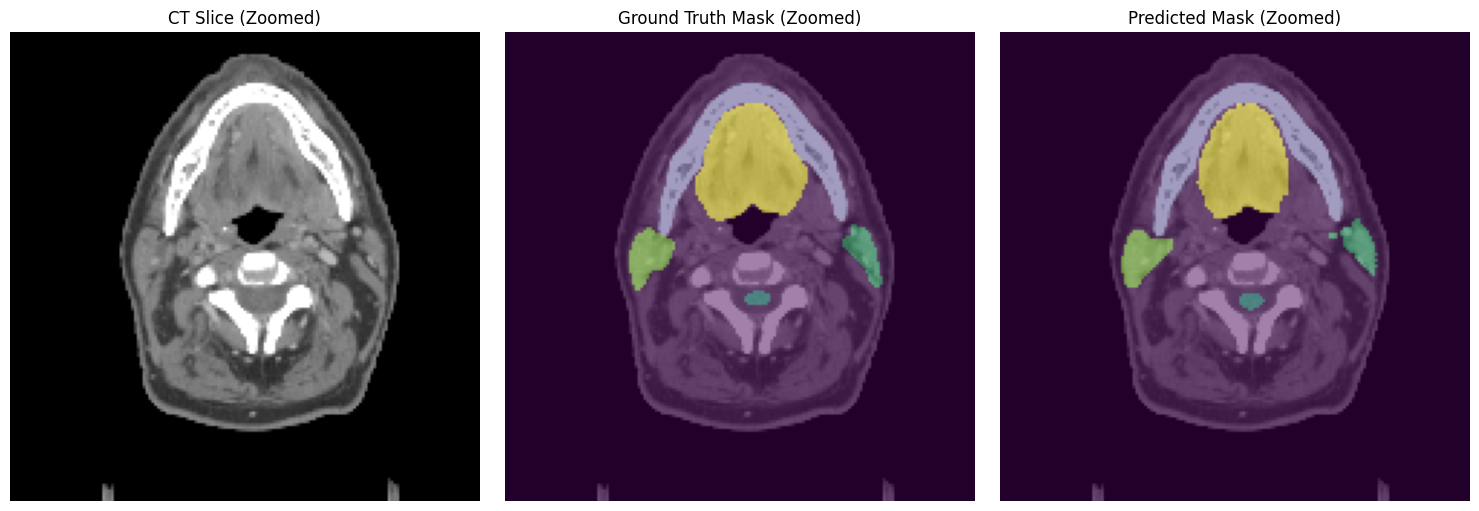

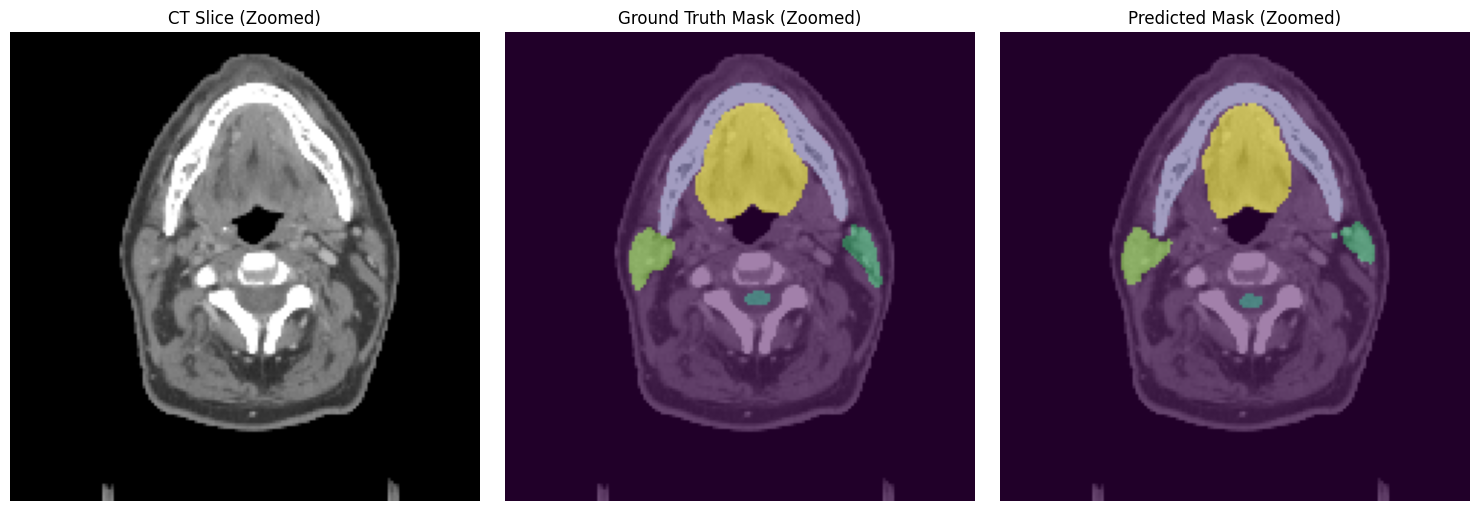

In [6]:
def zoom_center(img, zoom_factor=0.5):
    h, w = img.shape[:2]
    
    # New cropped size
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    
    # Center crop coordinates
    start_h = (h - new_h) // 2
    start_w = (w - new_w) // 2
    
    return img[start_h:start_h+new_h, start_w:start_w+new_w]

# Apply zoom
for model_name, result in results.items():
    pred_slice = result["pred_slice"]
    ct_zoom = zoom_center(ct_slice, 0.35)
    gt_zoom = zoom_center(gt_slice, 0.35)
    pred_zoom = zoom_center(pred_slice, 0.35)

    plt.figure(figsize=(15,5))

    # CT
    plt.subplot(1,3,1)
    plt.imshow(ct_zoom, cmap='gray')
    plt.title("CT Slice (Zoomed)")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(ct_zoom, cmap='gray')
    plt.imshow(gt_zoom, alpha=0.5)
    plt.title("Ground Truth Mask (Zoomed)")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(ct_zoom, cmap='gray')
    plt.imshow(pred_zoom, alpha=0.5)
    plt.title("Predicted Mask (Zoomed)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
# for model_name, result in results.items():
#     pred_slice = result["pred_slice"]
#     plt.figure(figsize=(15,5))

#     # CT
#     plt.subplot(1,3,1)
#     plt.imshow(ct_slice, cmap='gray')
#     plt.title(f"CT Slice\n{model_name}")
#     plt.axis("off")

#     # Ground Truth
#     plt.subplot(1,3,2)
#     plt.imshow(ct_slice, cmap='gray')
#     plt.imshow(gt_slice, alpha=0.5)
#     plt.title("Ground Truth Mask")
#     plt.axis("off")

#     # Prediction
#     plt.subplot(1,3,3)
#     plt.imshow(ct_slice, cmap='gray')
#     plt.imshow(pred_slice, alpha=0.5)
#     plt.title("Predicted Mask")
#     plt.axis("off")

#     plt.tight_layout()
#     plt.show()


Difference map for 04_iw


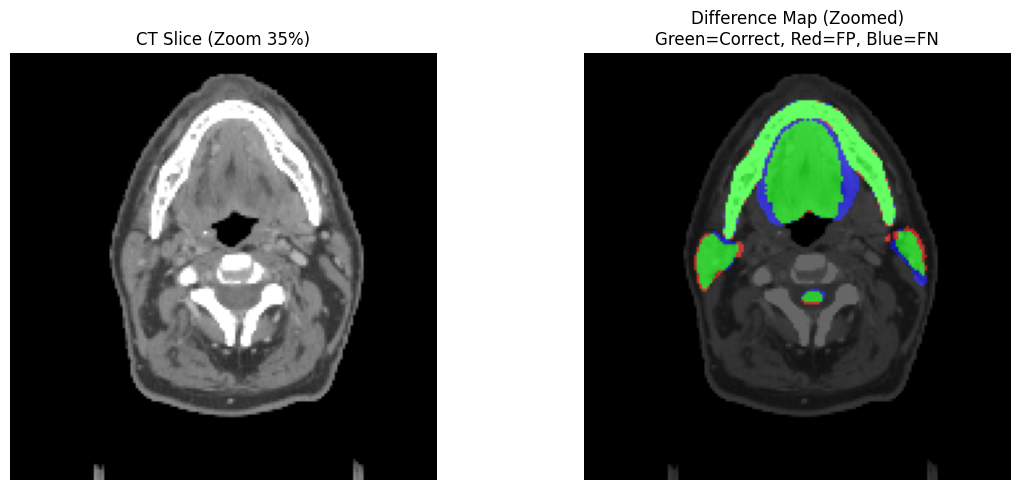

Difference map for 04_rw


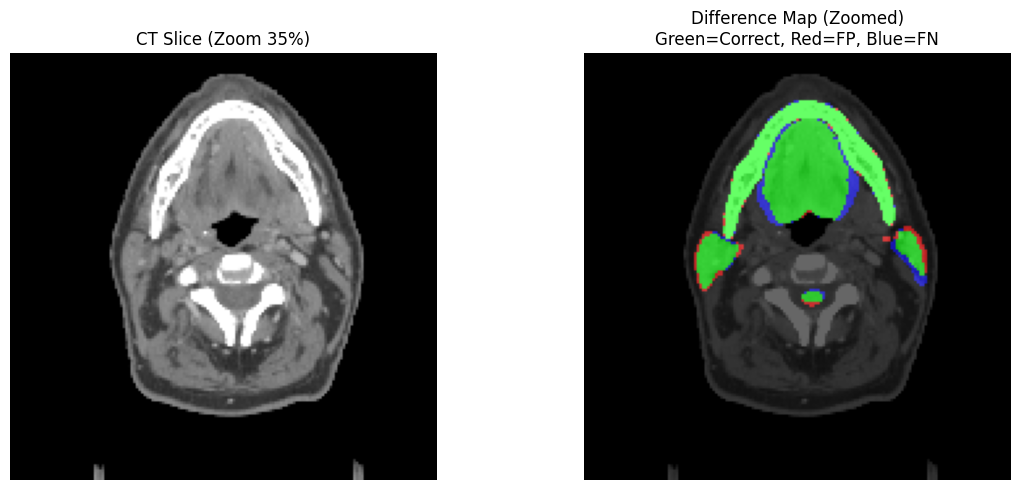

Difference map for 04_sc


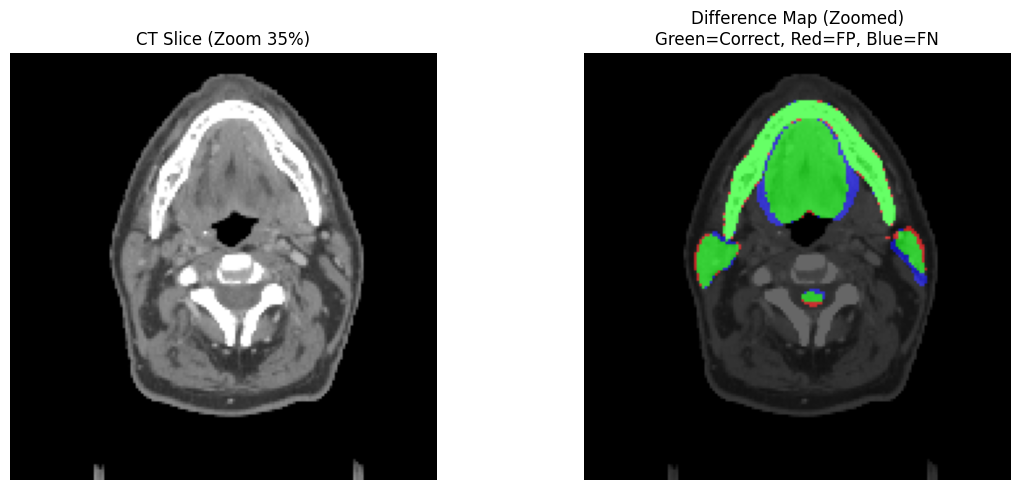

Difference map for 05_sc


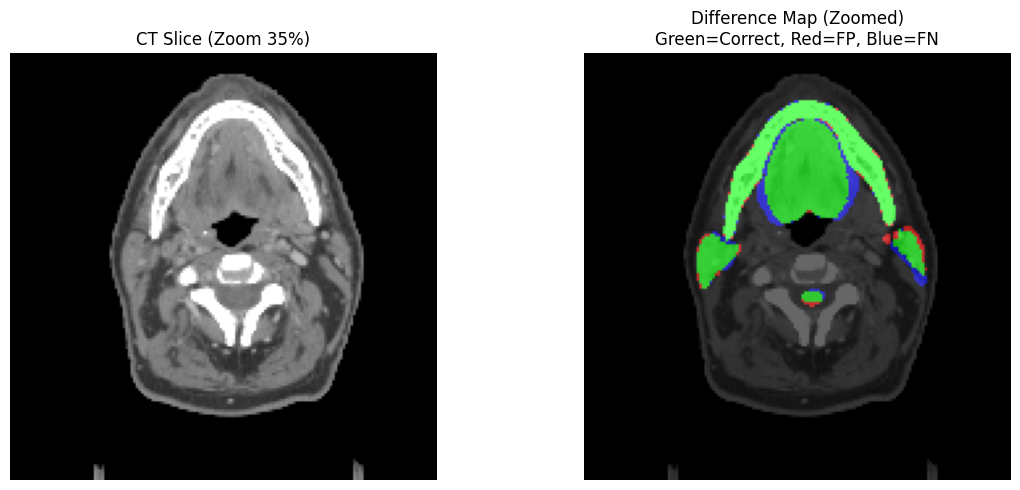

Difference map for 06_iw


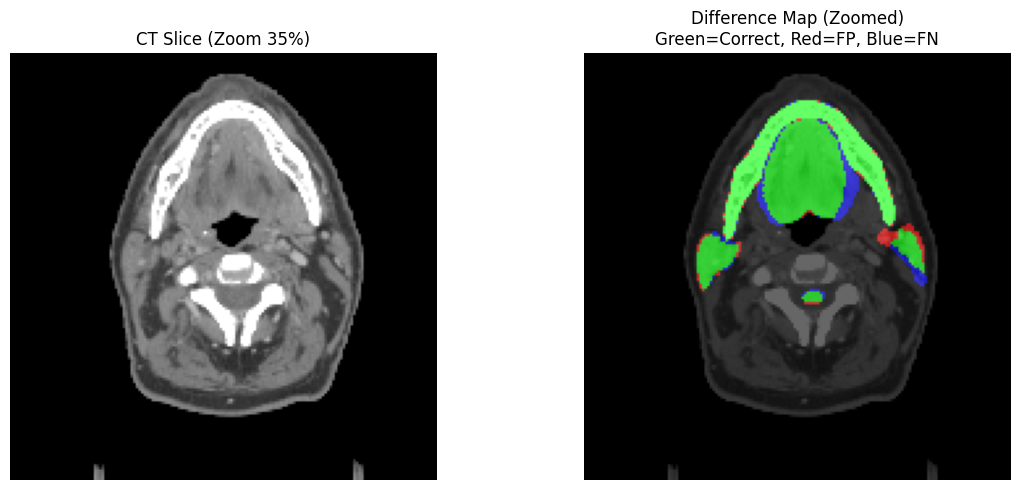

Difference map for 06_rw


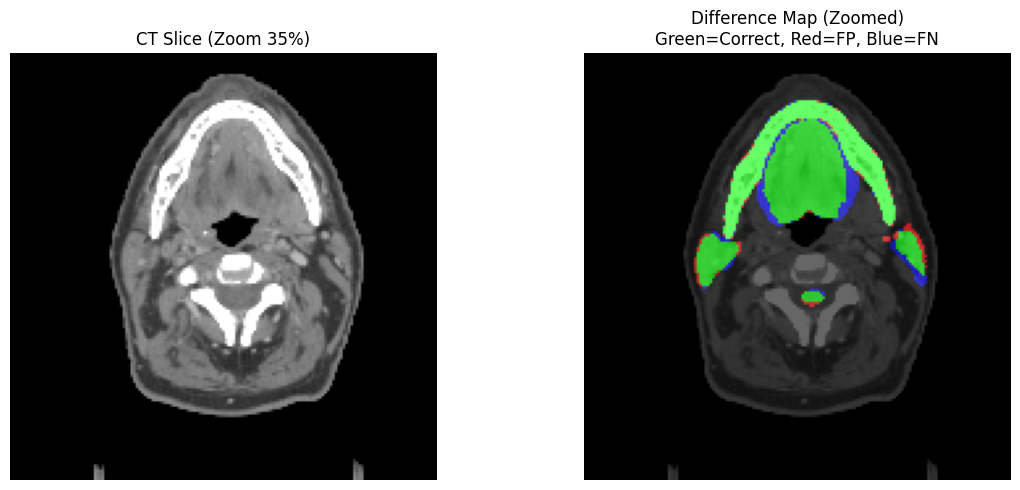

Difference map for 06_sc


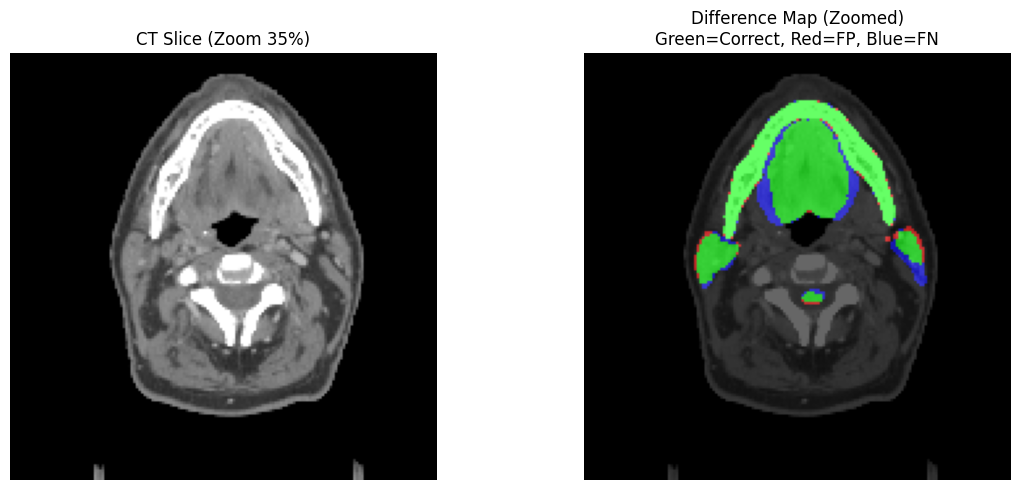

In [8]:
for model_name, result in results.items():
    print(f"Difference map for {model_name}")
    show_difference_map(ct_slice, gt_slice, result["pred_slice"],zoom_factor=0.35)
